# Seaborn Line and 2D Plot Examples

This notebook demonstrates simple Seaborn options for line plots and 2D visualizations. It covers palette selection, line style control, and common 2D plot types such as scatter plots, contour plots, and heatmaps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='darkgrid', palette='deep')
plt.rcParams.update({'font.size': 12})

## Line plot examples

Compare several Seaborn palette and style options for line plots.

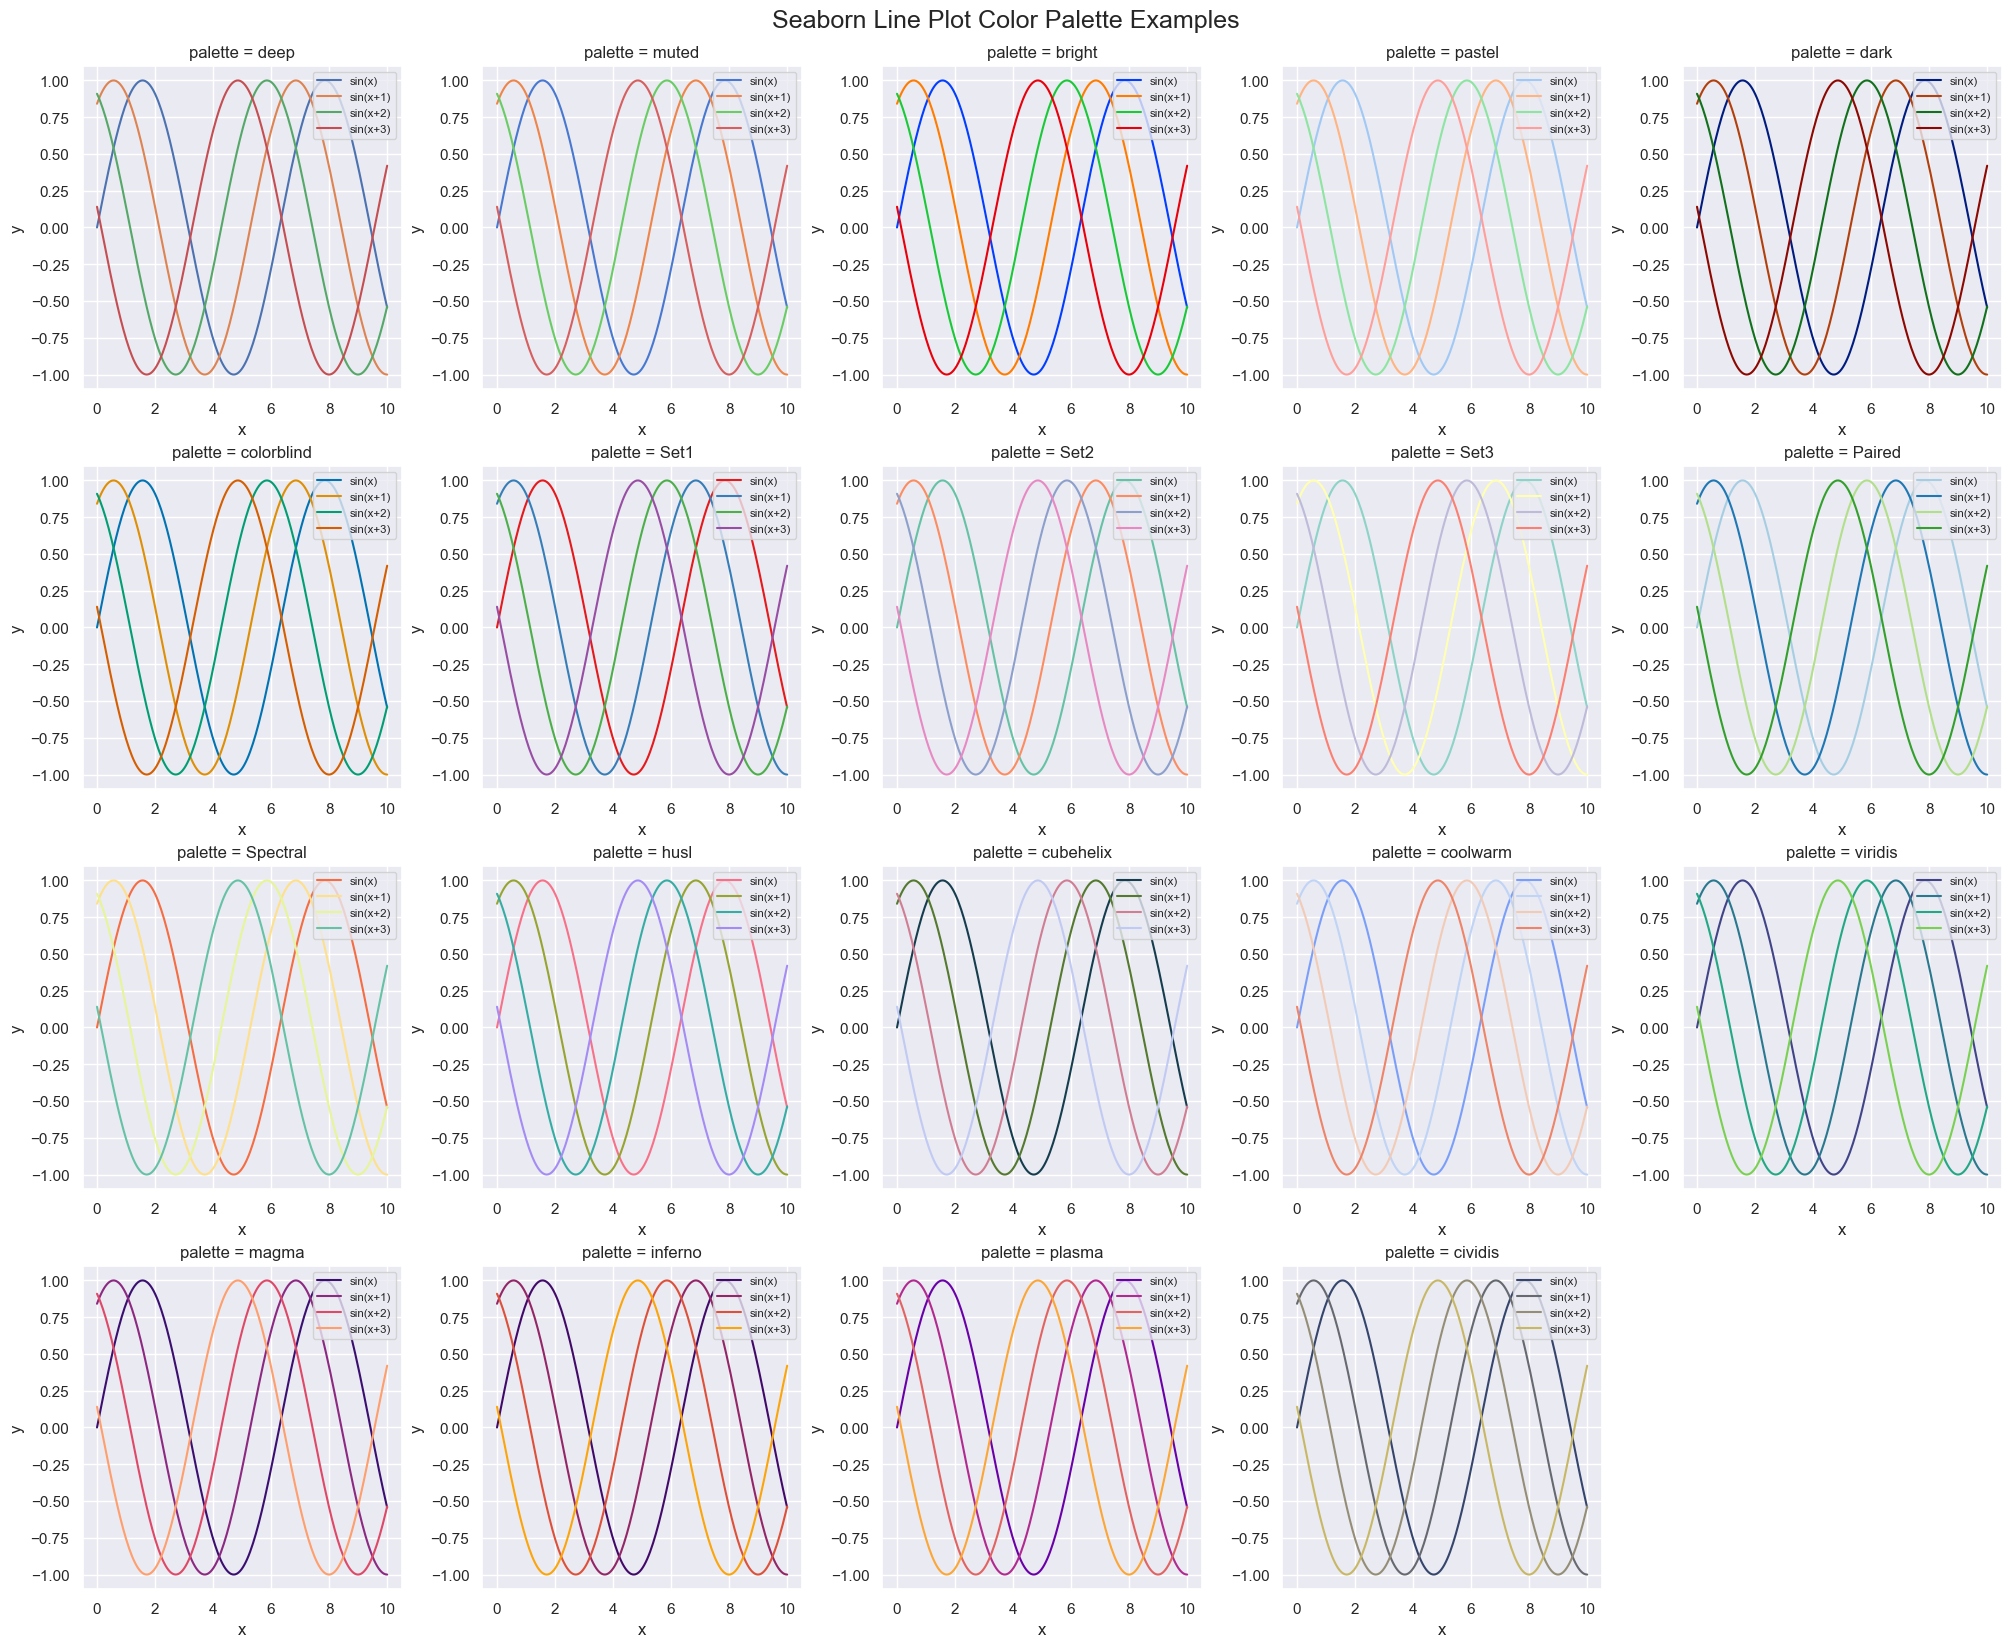

In [ ]:
x = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.sin(x + 1.0)
y3 = np.sin(x + 2.0)
y4 = np.sin(x + 3.0)

palettes = [
    'deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind',
    'Set1', 'Set2', 'Set3', 'Paired', 'Spectral',
    'husl', 'cubehelix', 'coolwarm', 'viridis', 'magma',
    'inferno', 'plasma', 'cividis', 'rocket', 'mako',
    'flare', 'crest', 'vlag', 'icefire'
]

ncols = 5
nrows = int(np.ceil(len(palettes) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), constrained_layout=True)
axes = axes.flatten()
for ax, pal in zip(axes, palettes):
    colors = sns.color_palette(pal, n_colors=4)
    for y, color, label in zip([y1, y2, y3, y4], colors, ['sin(x)', 'sin(x+1)', 'sin(x+2)', 'sin(x+3)']):
        ax.plot(x, y, label=label, color=color)
    ax.set_title(f'palette = {pal}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(loc='upper right', fontsize='x-small')

for ax in axes[len(palettes):]:
    fig.delaxes(ax)

plt.suptitle('Seaborn Line Plot Color Palette Examples', y=1.02, fontsize=18)
plt.show()

### Line styles and markers

Use explicit line styles, markers, and a Seaborn palette for better visual separation.

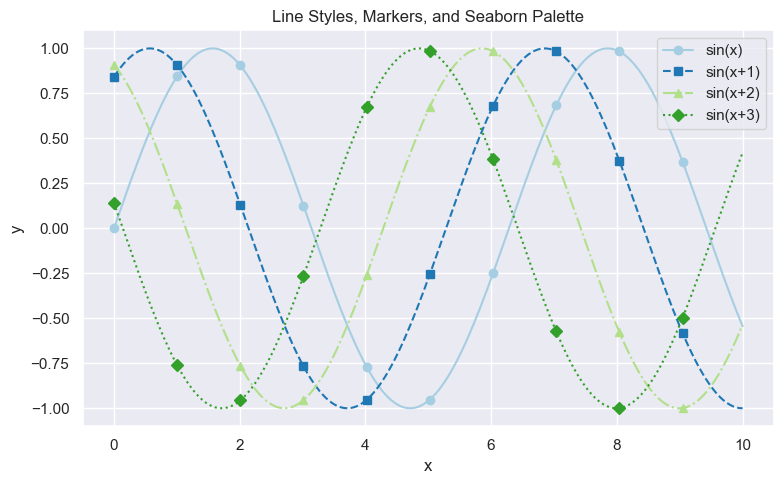

In [3]:
styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D']
palette = sns.color_palette('Paired', n_colors=4)

plt.figure(figsize=(8, 5))
for y, s, m, c, label in zip([y1, y2, y3, y4], styles, markers, palette, ['sin(x)', 'sin(x+1)', 'sin(x+2)', 'sin(x+3)']):
    plt.plot(x, y, linestyle=s, marker=m, color=c, label=label, markevery=20)

plt.title('Line Styles, Markers, and Seaborn Palette')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

## 2D plot examples

Demonstrate common 2D Seaborn plot types with simple synthetic data.

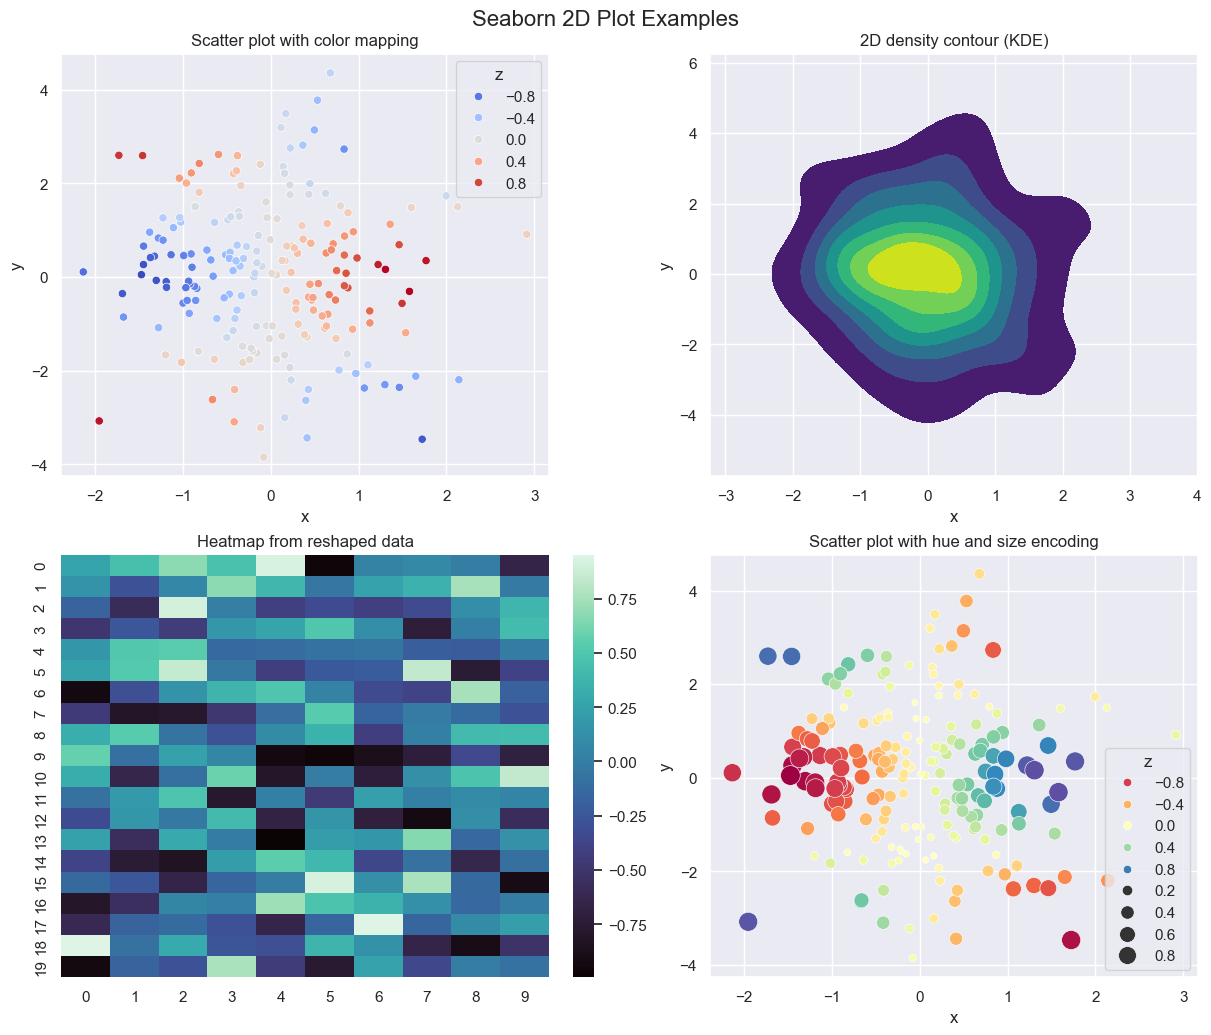

In [8]:
rng = np.random.default_rng(42)
x2 = rng.normal(loc=0, scale=1, size=200)
y2 = rng.normal(loc=0, scale=1.5, size=200)
z = np.sin(x2) * np.cos(y2)
df = pd.DataFrame({'x': x2, 'y': y2, 'z': z})

fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

sns.scatterplot(data=df, x='x', y='y', hue='z', palette='coolwarm', ax=axs[0, 0])
axs[0, 0].set_title('Scatter plot with color mapping')

sns.kdeplot(data=df, x='x', y='y', fill=True, cmap='viridis', thresh=0.05, levels=8, ax=axs[0, 1])
axs[0, 1].set_title('2D density contour (KDE)')

sns.heatmap(pd.DataFrame(z.reshape(20, 10)), cmap='mako', ax=axs[1, 0])
axs[1, 0].set_title('Heatmap from reshaped data')

sns.scatterplot(data=df, x='x', y='y', hue='z', palette='Spectral', size=np.abs(z), sizes=(20, 200), ax=axs[1, 1])
axs[1, 1].set_title('Scatter plot with hue and size encoding')

plt.suptitle('Seaborn 2D Plot Examples', y=1.02, fontsize=16)
plt.show()

## Notes

- Use `sns.set_theme()` to set the overall style and color palette.
- Use `sns.color_palette()` to generate a list of colors for explicit control.
- Combine `linestyle`, `marker`, and `color` for more distinct lines.
- Common 2D plots include `scatterplot`, `kdeplot`, and `heatmap`.